importing pandas , numpy,matplotlib,seaborn and warnings


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Import the CSV data as pandas dataframe


In [6]:
df=pd.read_csv("data\stud.csv")

In [7]:
df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


Checking missing values


In [8]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

Checking duplicates

In [12]:
df.duplicated().sum()

0

##check data type


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


##checking the number of unique values of each column

In [15]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [16]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [18]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [19]:
print("categories in 'gender' variable:" , end=" ")
print(df['gender'].unique())

print("categories in 'race_ethnicity' variable:" , end=" ")
print(df['race_ethnicity'].unique())


print("categories in 'parental_level_of_education' varaible:" , end=" ")
print(df["parental_level_of_education"].unique())

print("categories in 'lunch' varaible:" , end=" ")
print(df["lunch"].unique())

print("categories in 'test_preparation_course' varaible:" , end=" ")
print(df["test_preparation_course"].unique())

categories in 'gender' variable: ['female' 'male']
categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental_level_of_education' varaible: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' varaible: ['standard' 'free/reduced']
categories in 'test_preparation_course' varaible: ['none' 'completed']


In [21]:
##define numerical and categorical columns

num=[feature for feature in df.columns if df[feature].dtype !='O']
cat=[feature for feature in df.columns if df[feature].dtype=='O']

print('we have {} numerical features: {} '.format (len(num),num))
print("we have {} categorical features:{} ".format (len(cat),cat))

we have 3 numerical features: ['math_score', 'reading_score', 'writing_score'] 
we have 5 categorical features:['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course'] 


In [22]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [24]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [27]:
reading_full=df[df['reading_score']==100].shape[0]
writing_full=df[df['writing_score']==100].shape[0]
math_full=df[df['math_score']==100].shape[0]

print(f"no. of students with full marks in maths: {math_full}")

print(f"no. of students with full marks in writing: {writing_full}")

print(f"no. of students with full marks in reading: {reading_full}")

no. of students with full marks in maths: 7
no. of students with full marks in writing: 14
no. of students with full marks in reading: 17


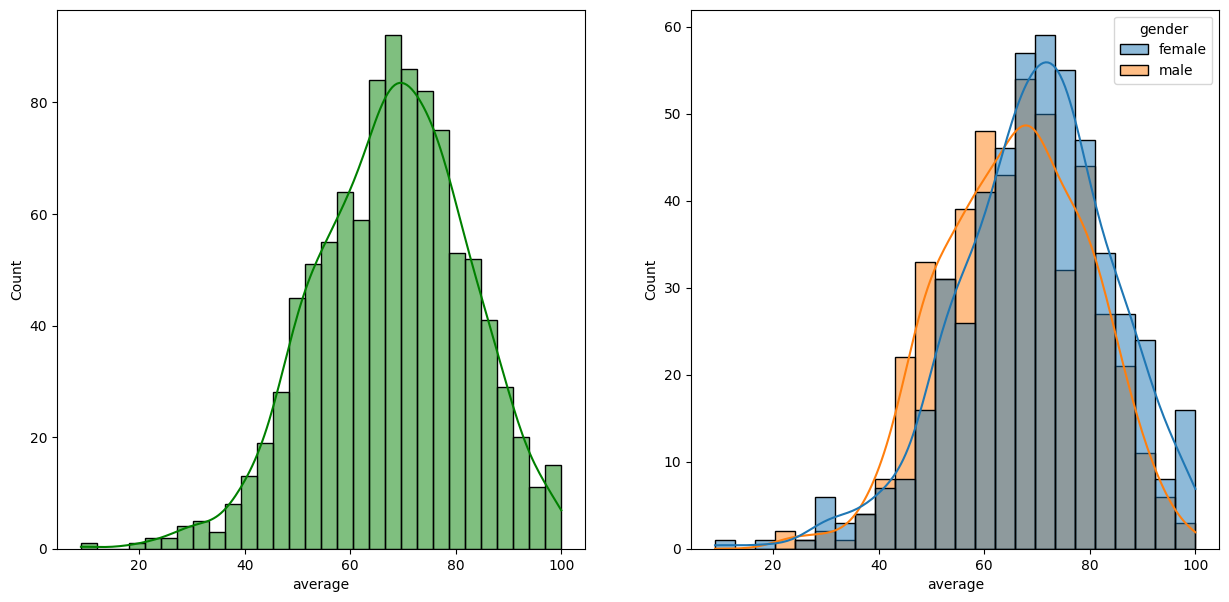

In [28]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

<Axes: xlabel='average', ylabel='Count'>

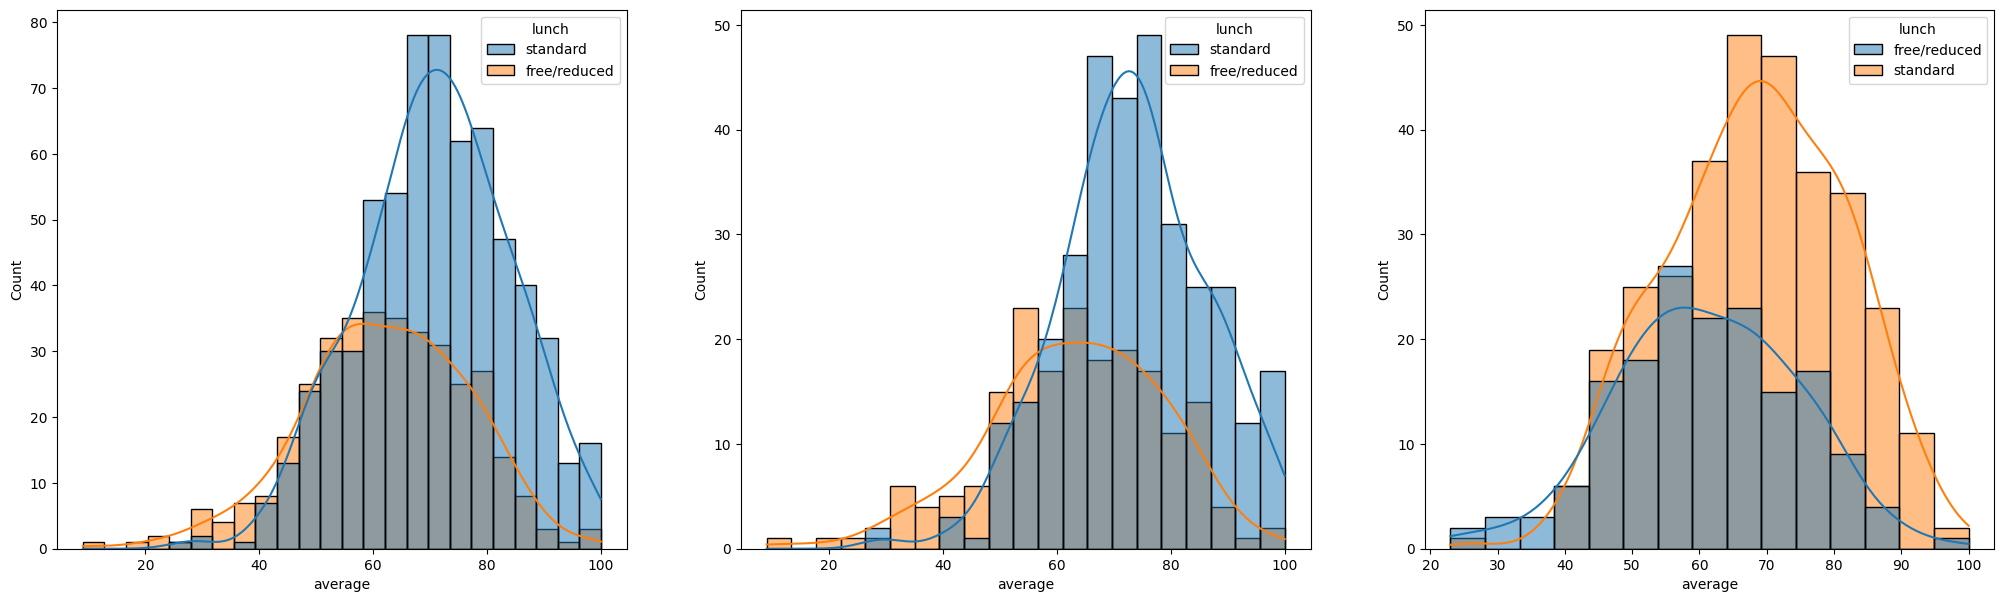

In [34]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df,x='average',kde=True,hue="lunch")
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue="lunch")
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue="lunch")



<Axes: xlabel='average', ylabel='Count'>

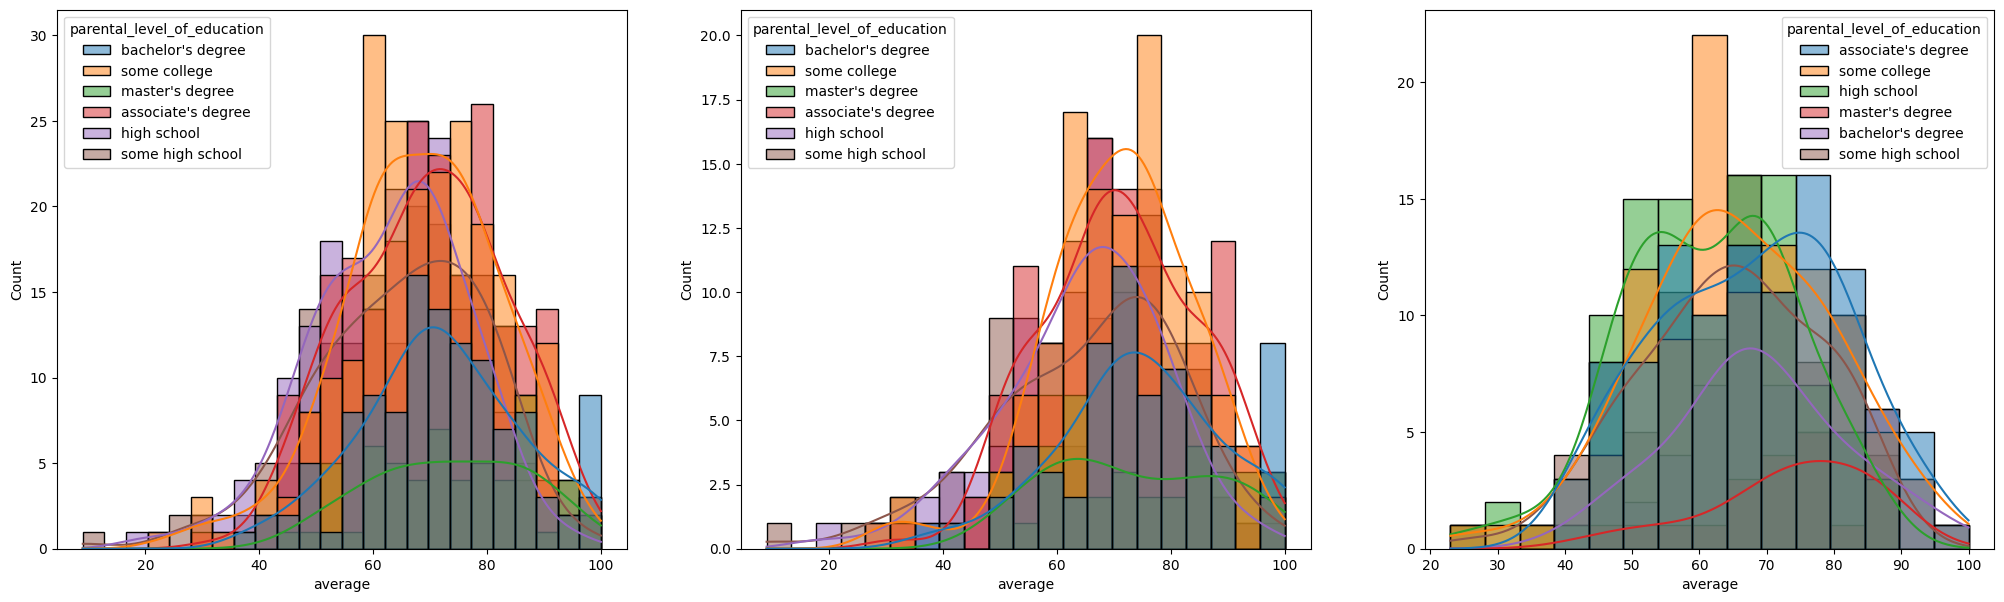

In [38]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average',hue='parental_level_of_education',kde=True)
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average',hue='parental_level_of_education',kde=True)

<Axes: xlabel='average', ylabel='Count'>

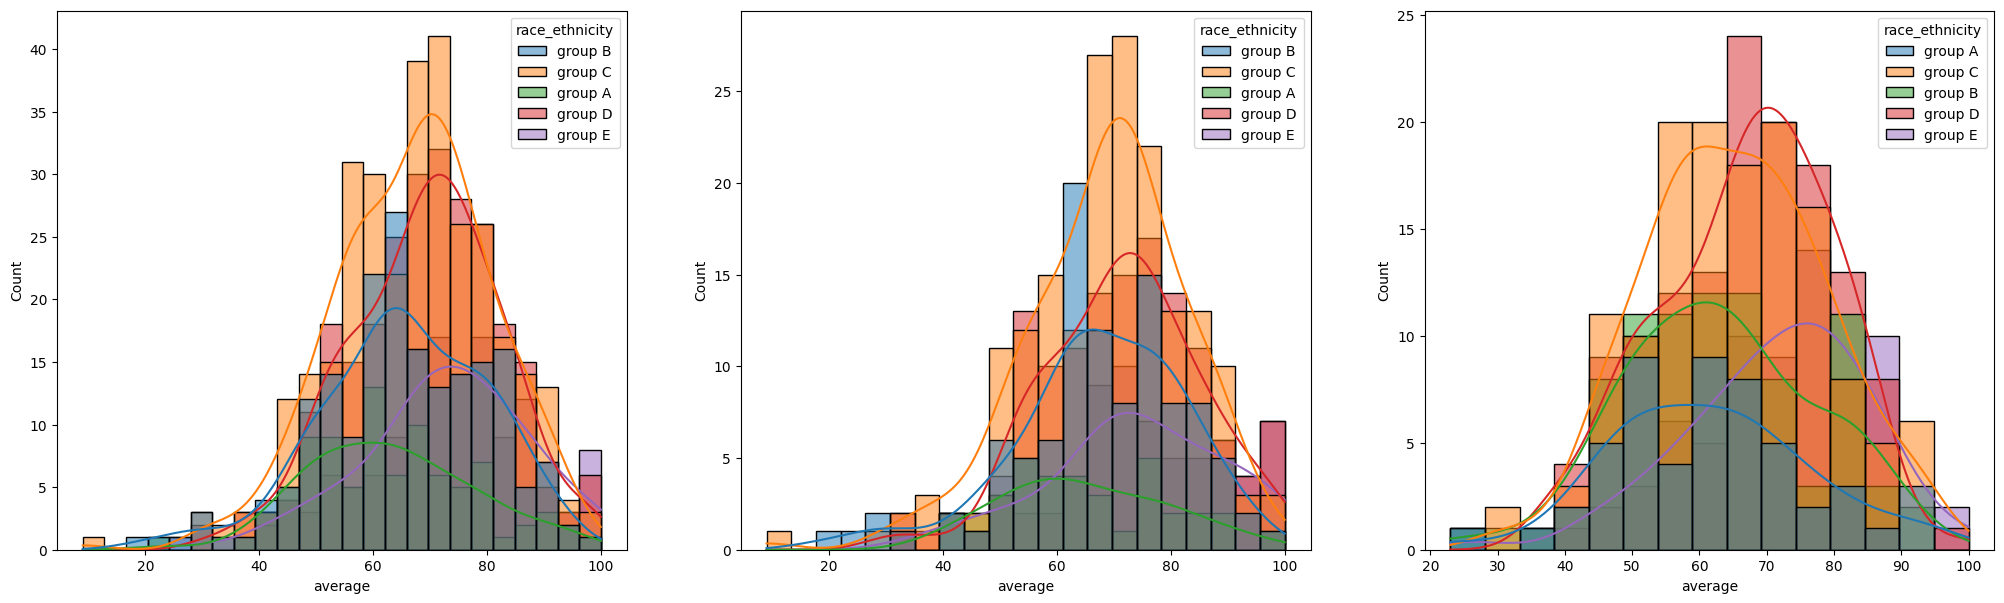

In [42]:
plt.subplots(1,3,figsize=(25,7))
plt.subplot(131)
sns.histplot(data=df,kde=True,x='average',hue='race_ethnicity')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average',hue='race_ethnicity',kde=True)
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average',hue='race_ethnicity',kde=True)

<Axes: title={'center': 'writing score'}, ylabel='writing_score'>

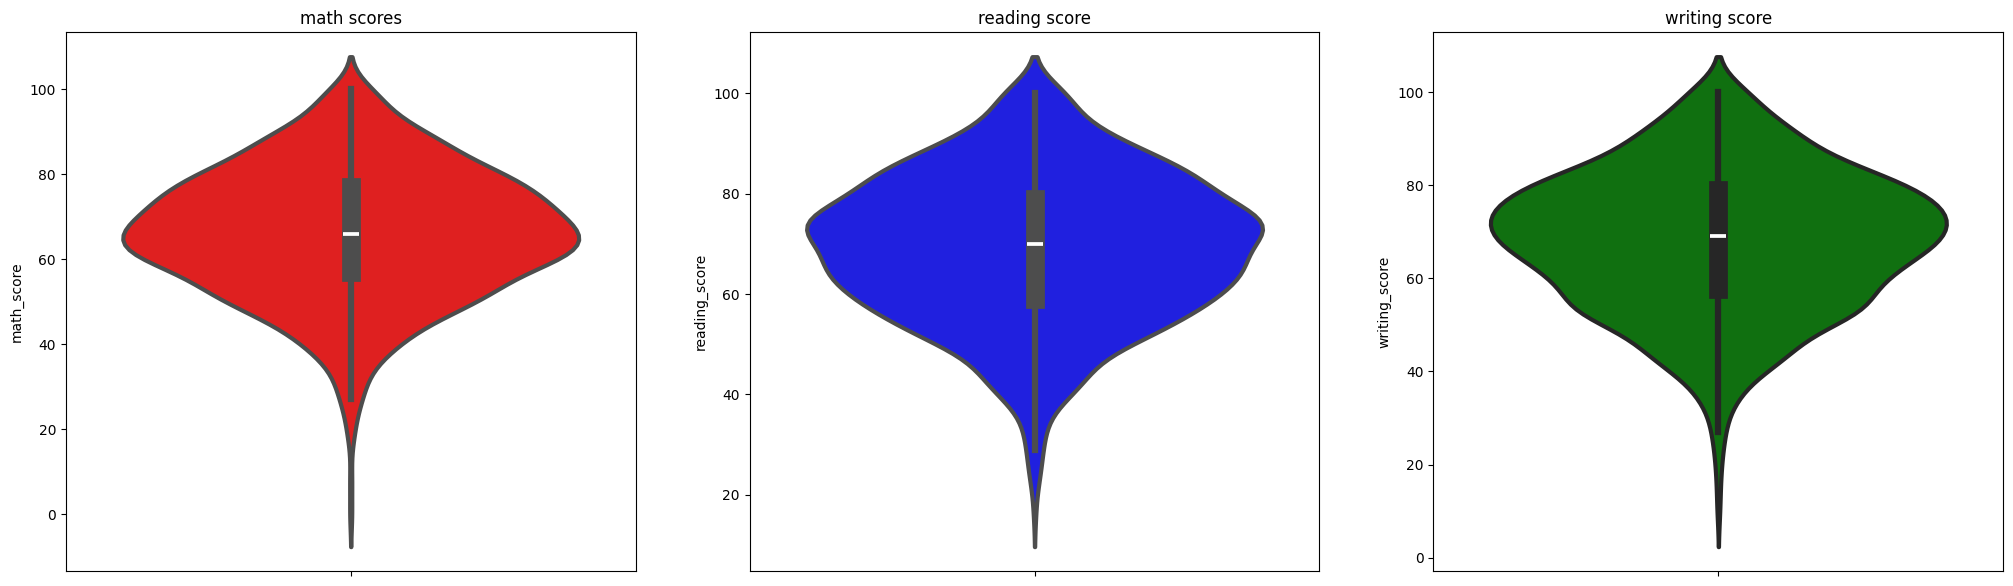

In [47]:
plt.figure(figsize=(25,7))
plt.subplot(131)
plt.title("math scores")
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(132)
plt.title("reading score")
sns.violinplot(y='reading_score',data=df,color='blue',linewidth=3)
plt.subplot(133)
plt.title("writing score")
sns.violinplot(y='writing_score',data=df,color='green',linewidth=3)

In [70]:
df['parental_level_of_education'].value_counts()

parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x20800e40190>,
 [Text(0.8341981156790161, 0.717017087521336, 'some college'),
  Text(-0.5717990621018805, 0.939705183863221, "associate's degree"),
  Text(-1.0543739750814827, -0.3135211646298753, 'high school'),
  Text(-0.11383566476996158, -1.0940938905900084, 'some high school'),
  Text(0.8112644257554884, -0.7428660925790178, "bachelor's degree"),
  Text(1.0811581857178525, -0.20272389463327067, "master's degree")],
 [Text(0.45501715400673604, 0.3911002295570923, '22.60%'),
  Text(-0.31189039751011655, 0.5125664639253932, '22.20%'),
  Text(-0.5751130773171723, -0.1710115443435683, '19.60%'),
  Text(-0.062092180783615405, -0.5967784857763682, '17.90%'),
  Text(0.44250786859390273, -0.4051996868612824, '11.80%'),
  Text(0.5897226467551923, -0.1105766697999658, '5.90%')])

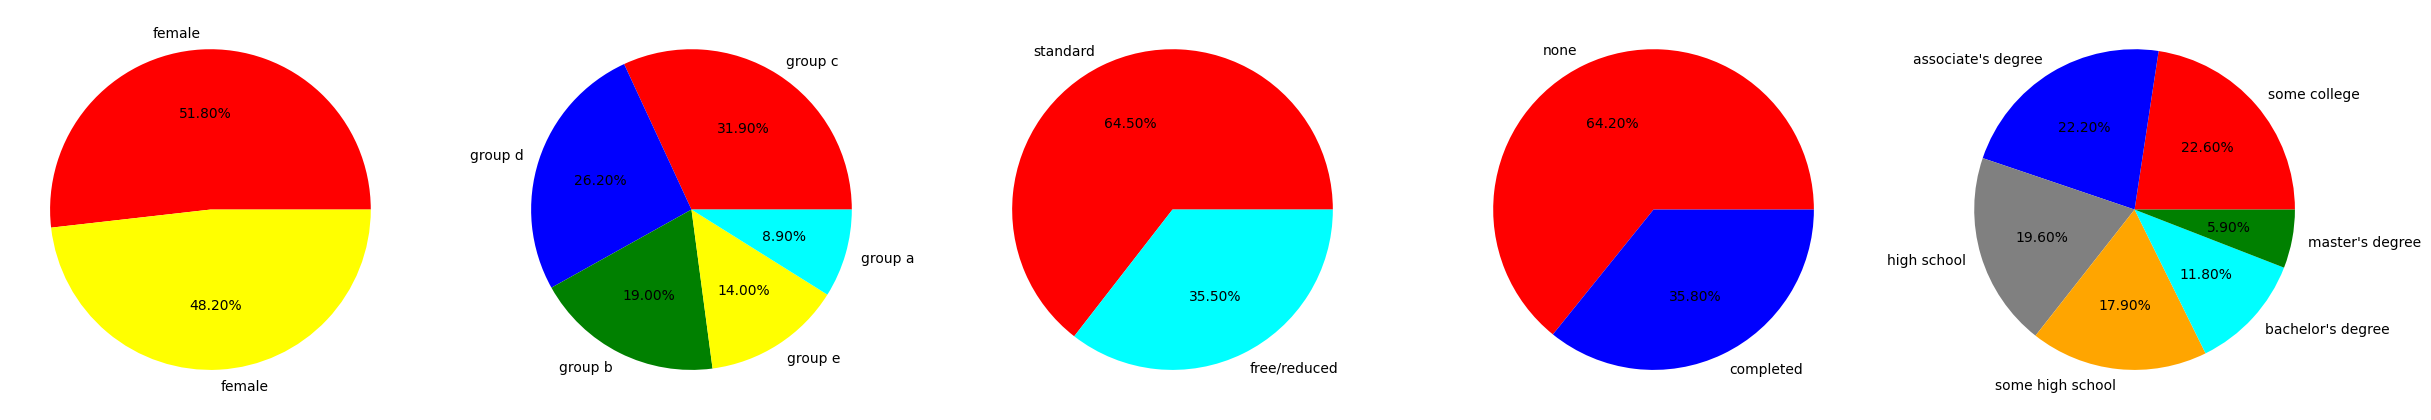

In [73]:
##pieplot

plt.rcParams['figure.figsize']=(30,12)


plt.subplot(151)
size=df['gender'].value_counts()
labels='female','female'
color=['red','yellow']
plt.pie(size,labels=labels,colors=color,autopct='%.2f%%')
plt.axis('off')

plt.subplot(152)
size=df['race_ethnicity'].value_counts()
labels='group c','group d','group b','group e','group a'
color=['red','blue','green','yellow','cyan']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')

plt.subplot(153)
size=df['lunch'].value_counts()
labels='standard','free/reduced'
color=['red','cyan']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')

plt.subplot(154)
size=df['test_preparation_course'].value_counts()
labels='none','completed',
color=['red','blue']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')

plt.subplot(155)
size=df['parental_level_of_education'].value_counts()
labels='some college',"associate's degree",'high school','some high school',"bachelor's degree","master's degree"
color=['red','blue','grey','orange','cyan','green']
plt.pie(size,colors=color,labels=labels,autopct='%.2f%%')

([<matplotlib.patches.Wedge at 0x208010b7d00>,
 [Text(-0.06217041096298424, 1.0982417038160106, 'female'),
  Text(0.06217041096298411, -1.0982417038160106, 'male')],
 [Text(-0.033911133252536856, 0.5990409293541875, '51.80%'),
  Text(0.033911133252536786, -0.5990409293541875, '48.20%')])

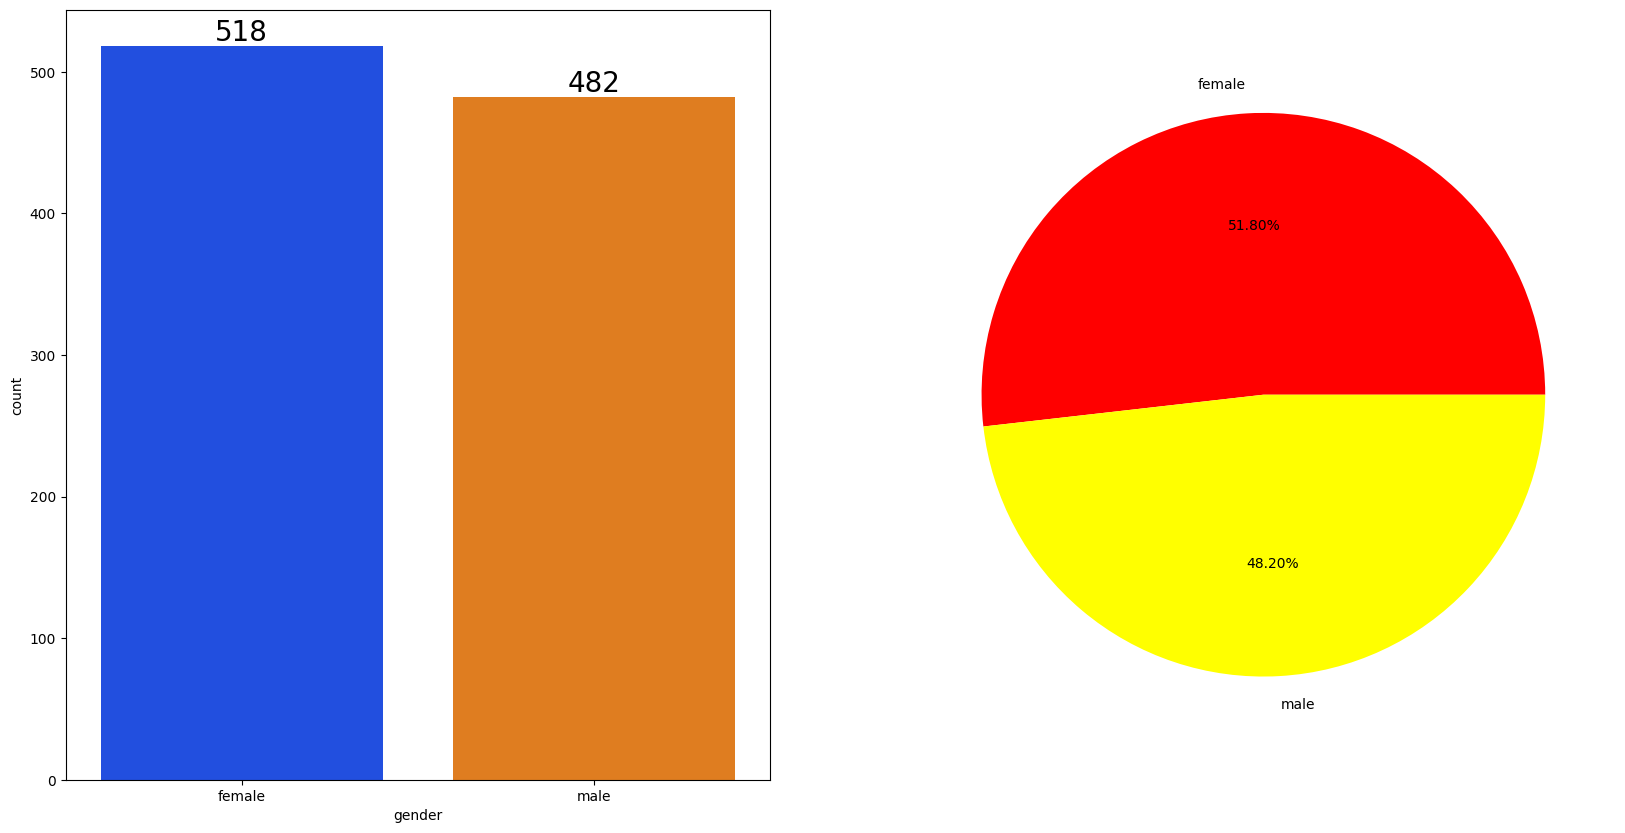

In [78]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette='bright',ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

plt.pie(x=df['gender'].value_counts(),labels=['female','male'],colors=['red','yellow'],autopct='%.2f%%')

In [81]:
gender_group = df.groupby('gender')[['average','math_score']].mean()
gender_group

,average,math_score
gender,,
female,69.569498,63.633205
male,65.837483,68.728216


In [ ]:
plt.figure(figsize=(10,8))
X=['total_average','math_average']
